# Análisis de resultados sintéticos

Este notebook analiza los resultados obtenidos al aplicar los dos métodos de estimación de movimiento sobre los vídeos sintéticos.

Los métodos comparados son:

- diferencia de imágenes;
- flujo óptico Lucas-Kanade.

Para cada condición se utilizan dos ejemplos sintéticos diferentes:

- objeto 1: círculo sobre fondo oscuro;
- objeto 2: cuadrado sobre fondo azul.

Ambos objetos se evalúan en los mismos escenarios: movimiento normal, ruido, cambio de iluminación y movimiento rápido.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_dir = current_dir.parent
else:
    project_dir = current_dir

plots_dir = project_dir / "outputs" / "plots" / "synthetic"
plots_dir.mkdir(parents=True, exist_ok=True)

summary_path = plots_dir / "synthetic_experiments_summary.csv"

print("Directorio del proyecto:", project_dir)
print("Ruta del resumen sintético:", summary_path)
print("Existe el archivo:", summary_path.exists())

if not summary_path.exists():
    raise FileNotFoundError(
        "No se encontró el archivo de resumen. Ejecuta primero: python src/run_synthetic_experiments.py"
    )

summary_df = pd.read_csv(summary_path)

print("Columnas:", summary_df.columns.tolist())
summary_df

Directorio del proyecto: c:\Users\34689\Desktop\Glole\U\masterus\percep
Ruta del resumen sintético: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\synthetic_experiments_summary.csv
Existe el archivo: True
Columnas: ['scenario', 'method', 'detections', 'mean_displacement', 'median_displacement', 'p95_displacement', 'max_displacement', 'mean_area', 'mean_points_per_frame']


,scenario,method,detections,mean_displacement,median_displacement,p95_displacement,max_displacement,mean_area,mean_points_per_frame
0,synthetic_clean_1,frame_difference,176,7.621300,7.615773,14.317821,18.681542,2782.982955,NaN
1,synthetic_clean_1,lucas_kanade,179,6.689177,7.279893,9.487194,9.499688,NaN,8.000000
2,synthetic_clean_2,frame_difference,174,10.436935,5.000000,30.016662,55.145263,3388.281609,NaN
3,synthetic_clean_2,lucas_kanade,179,4.239102,4.243590,5.830089,5.846732,NaN,6.000000
4,synthetic_noisy_1,frame_difference,176,7.845418,7.615773,15.297059,27.018512,2771.048295,NaN
5,synthetic_noisy_1,lucas_kanade,179,6.689068,7.281499,9.494237,9.558542,NaN,8.000000
6,synthetic_noisy_2,frame_difference,174,11.348262,5.000000,31.048349,58.137767,3269.712644,NaN
7,synthetic_noisy_2,lucas_kanade,179,4.752524,4.238457,11.433777,44.419624,NaN,14.022346
8,synthetic_light_change_1,frame_difference,176,7.925177,7.615773,15.297059,25.709920,2636.511364,NaN
9,synthetic_light_change_1,lucas_kanade,179,6.688920,7.279391,9.487752,9.571553,NaN,8.000000


In [2]:
def get_condition(scenario_name):
    if "clean" in scenario_name:
        return "Limpio"
    if "noisy" in scenario_name:
        return "Ruido"
    if "light_change" in scenario_name:
        return "Cambio de luz"
    if "fast" in scenario_name:
        return "Movimiento rápido"
    return "Otro"


condition_order = [
    "Limpio",
    "Ruido",
    "Cambio de luz",
    "Movimiento rápido",
]

method_labels = {
    "frame_difference": "Diferencia de imágenes",
    "lucas_kanade": "Lucas-Kanade",
}

summary_df["condition"] = summary_df["scenario"].apply(get_condition)

summary_df["condition"] = pd.Categorical(
    summary_df["condition"],
    categories=condition_order,
    ordered=True
)

summary_df["method_label"] = summary_df["method"].map(method_labels)

summary_df = summary_df.sort_values(["condition", "scenario", "method"])

summary_df

,scenario,method,detections,mean_displacement,median_displacement,p95_displacement,max_displacement,mean_area,mean_points_per_frame,condition,method_label
0,synthetic_clean_1,frame_difference,176,7.621300,7.615773,14.317821,18.681542,2782.982955,NaN,Limpio,Diferencia de imágenes
1,synthetic_clean_1,lucas_kanade,179,6.689177,7.279893,9.487194,9.499688,NaN,8.000000,Limpio,Lucas-Kanade
2,synthetic_clean_2,frame_difference,174,10.436935,5.000000,30.016662,55.145263,3388.281609,NaN,Limpio,Diferencia de imágenes
3,synthetic_clean_2,lucas_kanade,179,4.239102,4.243590,5.830089,5.846732,NaN,6.000000,Limpio,Lucas-Kanade
4,synthetic_noisy_1,frame_difference,176,7.845418,7.615773,15.297059,27.018512,2771.048295,NaN,Ruido,Diferencia de imágenes
5,synthetic_noisy_1,lucas_kanade,179,6.689068,7.281499,9.494237,9.558542,NaN,8.000000,Ruido,Lucas-Kanade
6,synthetic_noisy_2,frame_difference,174,11.348262,5.000000,31.048349,58.137767,3269.712644,NaN,Ruido,Diferencia de imágenes
7,synthetic_noisy_2,lucas_kanade,179,4.752524,4.238457,11.433777,44.419624,NaN,14.022346,Ruido,Lucas-Kanade
8,synthetic_light_change_1,frame_difference,176,7.925177,7.615773,15.297059,25.709920,2636.511364,NaN,Cambio de luz,Diferencia de imágenes
9,synthetic_light_change_1,lucas_kanade,179,6.688920,7.279391,9.487752,9.571553,NaN,8.000000,Cambio de luz,Lucas-Kanade


In [3]:
summary_grouped = summary_df.groupby(
    ["condition", "method_label"],
    observed=True
).agg(
    detections=("detections", "mean"),
    mean_displacement=("mean_displacement", "mean"),
    median_displacement=("median_displacement", "mean"),
    p95_displacement=("p95_displacement", "mean"),
    max_displacement=("max_displacement", "mean"),
    mean_area=("mean_area", "mean"),
    mean_points_per_frame=("mean_points_per_frame", "mean"),
).reset_index()

summary_grouped

,condition,method_label,detections,mean_displacement,median_displacement,p95_displacement,max_displacement,mean_area,mean_points_per_frame
0,Limpio,Diferencia de imágenes,175.0,9.029118,6.307887,22.167242,36.913402,3085.632282,NaN
1,Limpio,Lucas-Kanade,179.0,5.464140,5.761742,7.658642,7.673210,NaN,7.000000
2,Ruido,Diferencia de imágenes,175.0,9.596840,6.307887,23.172704,42.578140,3020.380470,NaN
3,Ruido,Lucas-Kanade,179.0,5.720796,5.759978,10.464007,26.989083,NaN,11.011173
4,Cambio de luz,Diferencia de imágenes,167.0,9.815517,6.307887,23.277029,41.872196,2459.538910,NaN
5,Cambio de luz,Lucas-Kanade,179.0,5.464000,5.761754,7.659108,7.720244,NaN,7.000000
6,Movimiento rápido,Diferencia de imágenes,168.0,11.874899,10.979759,23.519004,50.072631,3313.076900,NaN
7,Movimiento rápido,Lucas-Kanade,179.0,8.811662,9.539468,13.098681,13.547685,NaN,7.000000


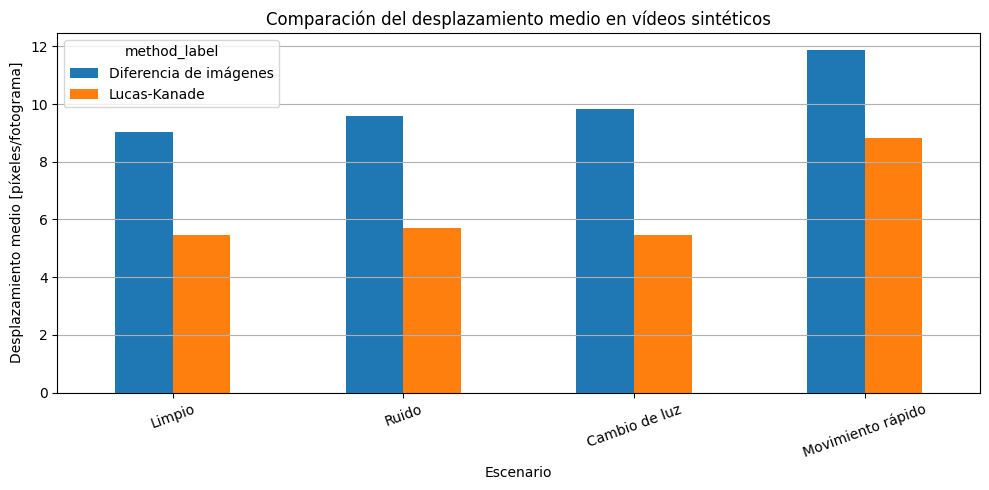

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\summary_mean_displacement.png


In [4]:
mean_disp_plot = plots_dir / "summary_mean_displacement.png"

pivot_mean = summary_grouped.pivot(
    index="condition",
    columns="method_label",
    values="mean_displacement"
)

pivot_mean.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Desplazamiento medio [píxeles/fotograma]")
plt.xlabel("Escenario")
plt.title("Comparación del desplazamiento medio en vídeos sintéticos")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(mean_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", mean_disp_plot)

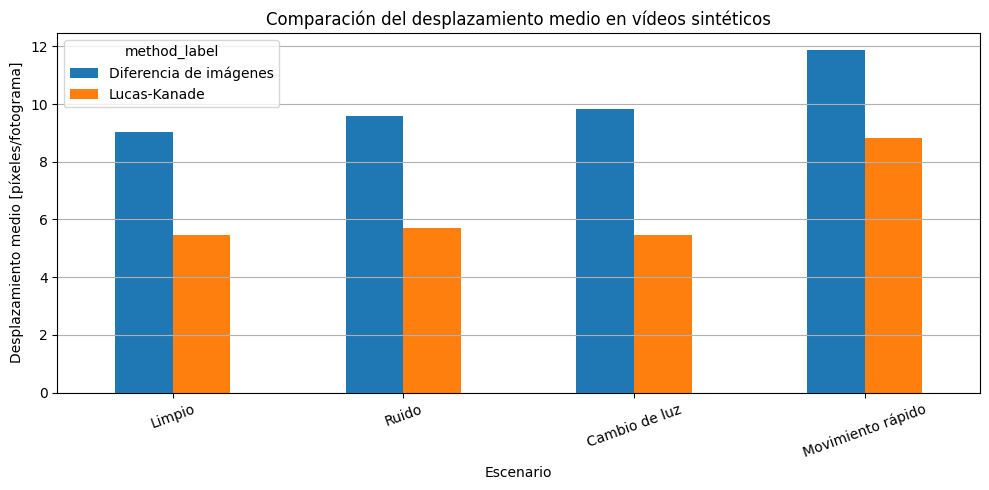

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\summary_mean_displacement.png


In [5]:
mean_disp_plot = plots_dir / "summary_mean_displacement.png"

pivot_mean = summary_grouped.pivot(
    index="condition",
    columns="method_label",
    values="mean_displacement"
)

pivot_mean.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Desplazamiento medio [píxeles/fotograma]")
plt.xlabel("Escenario")
plt.title("Comparación del desplazamiento medio en vídeos sintéticos")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(mean_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", mean_disp_plot)

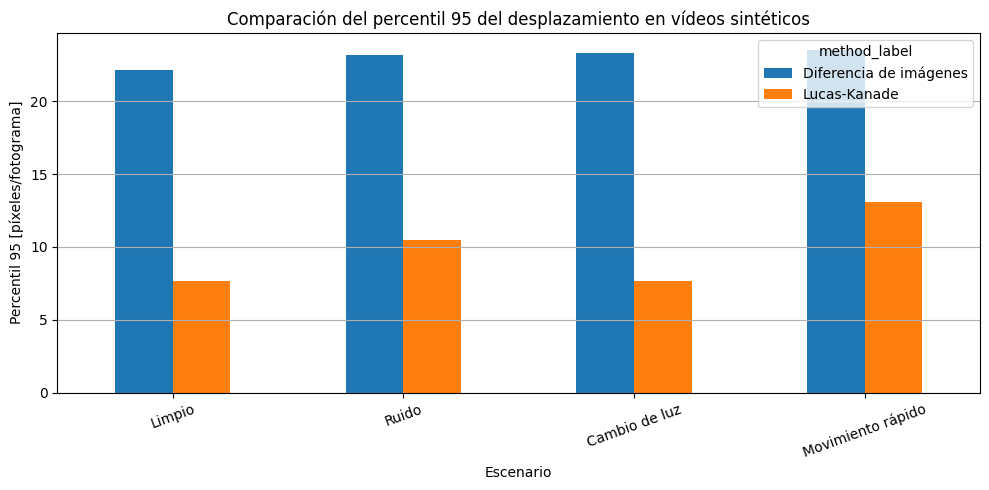

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\summary_p95_displacement.png


In [6]:
p95_disp_plot = plots_dir / "summary_p95_displacement.png"

pivot_p95 = summary_grouped.pivot(
    index="condition",
    columns="method_label",
    values="p95_displacement"
)

pivot_p95.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Percentil 95 [píxeles/fotograma]")
plt.xlabel("Escenario")
plt.title("Comparación del percentil 95 del desplazamiento en vídeos sintéticos")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(p95_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", p95_disp_plot)

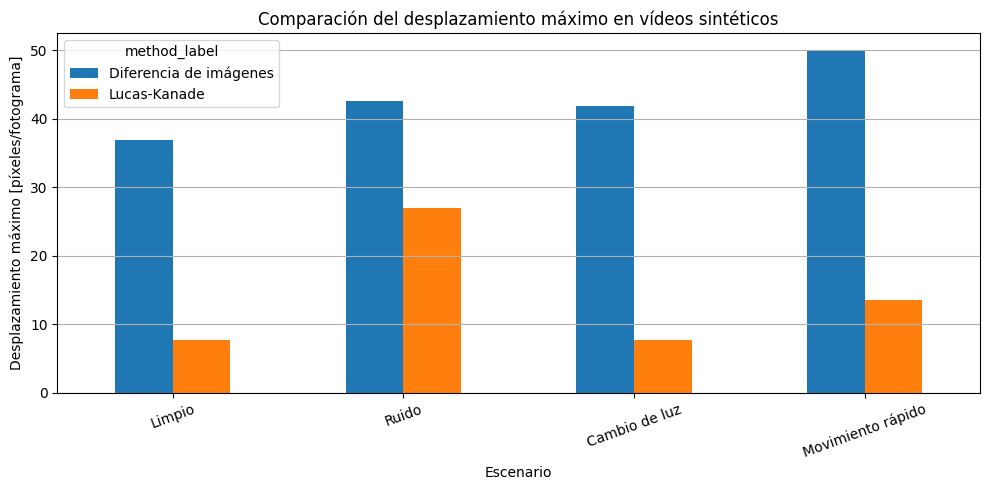

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\summary_max_displacement.png


In [7]:
max_disp_plot = plots_dir / "summary_max_displacement.png"

pivot_max = summary_grouped.pivot(
    index="condition",
    columns="method_label",
    values="max_displacement"
)

pivot_max.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Desplazamiento máximo [píxeles/fotograma]")
plt.xlabel("Escenario")
plt.title("Comparación del desplazamiento máximo en vídeos sintéticos")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(max_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", max_disp_plot)

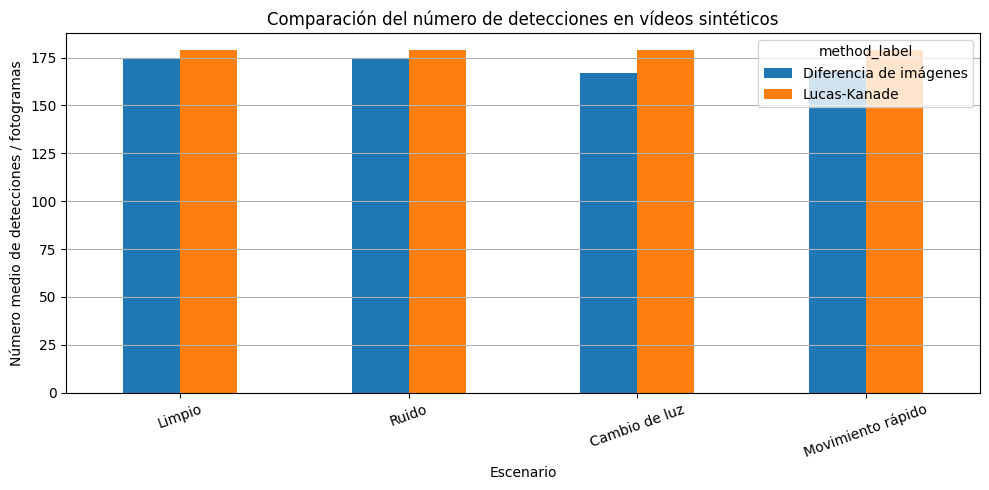

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\summary_detections.png


In [8]:
detections_plot = plots_dir / "summary_detections.png"

pivot_detections = summary_grouped.pivot(
    index="condition",
    columns="method_label",
    values="detections"
)

pivot_detections.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Número medio de detecciones / fotogramas")
plt.xlabel("Escenario")
plt.title("Comparación del número de detecciones en vídeos sintéticos")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(detections_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", detections_plot)

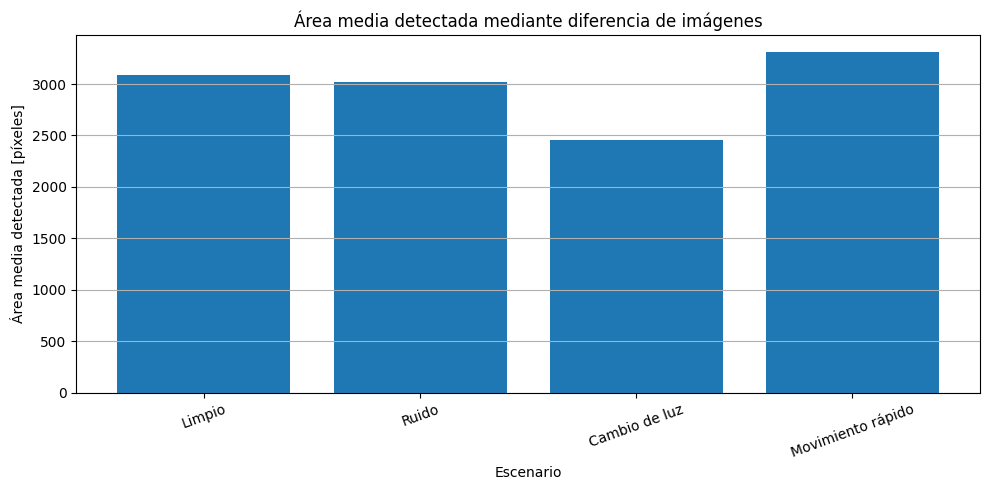

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\summary_frame_difference_mean_area.png


In [9]:
area_plot = plots_dir / "summary_frame_difference_mean_area.png"

frame_diff_df = summary_grouped[
    summary_grouped["method_label"] == "Diferencia de imágenes"
]

plt.figure(figsize=(10, 5))
plt.bar(frame_diff_df["condition"], frame_diff_df["mean_area"])

plt.ylabel("Área media detectada [píxeles]")
plt.xlabel("Escenario")
plt.title("Área media detectada mediante diferencia de imágenes")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(area_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", area_plot)

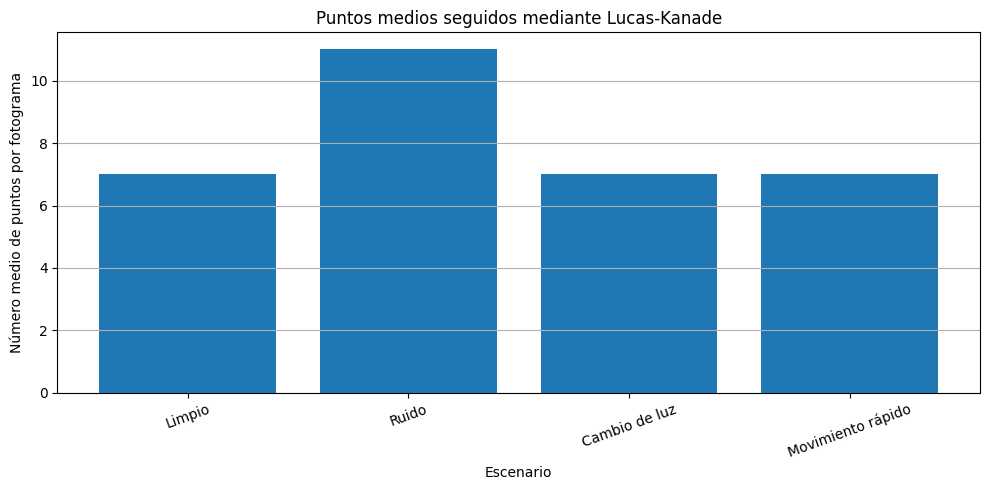

Gráfica guardada en: c:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\synthetic\summary_lucas_kanade_mean_points.png


In [10]:
points_plot = plots_dir / "summary_lucas_kanade_mean_points.png"

lk_df = summary_grouped[
    summary_grouped["method_label"] == "Lucas-Kanade"
]

plt.figure(figsize=(10, 5))
plt.bar(lk_df["condition"], lk_df["mean_points_per_frame"])

plt.ylabel("Número medio de puntos por fotograma")
plt.xlabel("Escenario")
plt.title("Puntos medios seguidos mediante Lucas-Kanade")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(points_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", points_plot)

## Conclusión del análisis sintético

Los vídeos sintéticos permiten evaluar los métodos en condiciones controladas. Al utilizar dos objetos diferentes y repetir los mismos escenarios para ambos, se evita que las conclusiones dependan de un único ejemplo.

La diferencia de imágenes funciona bien en condiciones limpias, pero puede verse afectada por ruido, cambios de iluminación o movimientos rápidos. Lucas-Kanade permite seguir puntos característicos del objeto, aunque también puede fallar si el objeto pierde textura, si aparecen puntos falsos por ruido o si el desplazamiento entre fotogramas es demasiado grande.

Este análisis sirve como paso previo al análisis con vídeos reales, donde aparecen dificultades adicionales como sombras, pequeñas variaciones de cámara, texturas reales y cambios de iluminación menos controlados.